In [2]:
from tensorflow.keras import datasets, layers, models
from pathlib import Path

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))
train_images, test_images = train_images / 255.0, test_images / 255.0

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.summary()
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=1)
model.evaluate(test_images, test_labels)

save_dir = Path('./code_res_imgs/_mnist')
save_dir.mkdir(parents=True, exist_ok=True)

save_direct = './code_res_imgs/_mnist'
model.save(save_direct + '/mnist_model.h5')

c:\Users\Jo\AppData\Local\Programs\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8905 - loss: 0.3491
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9794 - loss: 0.0650


In [3]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

save_dir = './code_res_imgs/_mnist'
model = load_model(save_dir + '/mnist_model.h5')

onDown = False
xset, yset = None, None
def onmouse(event, x, y, flags, params):
    global onDown, img1, xset, yset
    if event == cv2.EVENT_LBUTTONDOWN:
        onDown = True
    elif event == cv2.EVENT_MOUSEMOVE:
        if onDown == True:
            cv2.line(img1, (xset, yset), (x, y), (0, 0, 0), 5)
    elif event == cv2.EVENT_LBUTTONUP:
        onDown = False
    xset, yset = x, y

cv2.namedWindow('Input')
cv2.setMouseCallback('Input', onmouse)
width, height = 280, 280
img1 = np.ones((280, 280, 3), np.uint8) * 255
res_index = 1
while True:
    cv2.imshow('Input', img1)
    key = cv2.waitKey(1)
    if key == ord('r'):
        img1 = np.ones((280, 280, 3), np.uint8) * 255
    if key == ord('i'):
        x_resize = cv2.resize(img1, dsize=(28, 28), interpolation=cv2.INTER_AREA)
        x_gray = cv2.cvtColor(x_resize, cv2.COLOR_BGR2GRAY)
        x_gray = ~x_gray
        x = x_gray.reshape(1, 28, 28, 1)
        y = model.predict_classes(x)
        cv2.putText(img1, str(y), (10, 30), cv2.FONT_HERSHEY_COMPLEX, 1.0, (128, 128, 128), 2)
        cv2.imwrite(save_direct + '/' + str(res_index) + '.jpg', img1)
        res_index += 1
    if key == ord('q'):
        break

cv2.destroyAllWindows()

AttributeError: 'Sequential' object has no attribute 'predict_classes'

In [4]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

save_dir = './code_res_imgs/_mnist'
model = load_model(save_dir + '/mnist_model.h5')

onDown = False
xset, yset = None, None

def onmouse(event, x, y, flags, params):
    global onDown, img1, xset, yset
    if event == cv2.EVENT_LBUTTONDOWN:
        onDown = True
    elif event == cv2.EVENT_MOUSEMOVE:
        if onDown:
            cv2.line(img1, (xset, yset), (x, y), (0, 0, 0), 5)
    elif event == cv2.EVENT_LBUTTONUP:
        onDown = False
    xset, yset = x, y

cv2.namedWindow('Input')
cv2.setMouseCallback('Input', onmouse)
width, height = 280, 280
img1 = np.ones((height, width, 3), np.uint8) * 255
res_index = 1

while True:
    cv2.imshow('Input', img1)
    key = cv2.waitKey(1)

    if key == ord('r'):
        img1 = np.ones((height, width, 3), np.uint8) * 255

    if key == ord('i'):
        x_resize = cv2.resize(img1, dsize=(28, 28), interpolation=cv2.INTER_AREA)
        x_gray = cv2.cvtColor(x_resize, cv2.COLOR_BGR2GRAY)
        x_gray = ~x_gray
        x = x_gray.astype('float32') / 255.0   # 정규화 (모델 학습 방식에 맞춰 필요시 조정)
        x = x.reshape(1, 28, 28, 1)

        # predict_classes 대체
        probs = model.predict(x)               # shape: (1, 10)
        y = int(np.argmax(probs, axis=-1)[0])  # 예측 숫자 클래스 [web:9][web:21]

        cv2.putText(img1, str(y), (10, 30),
                    cv2.FONT_HERSHEY_COMPLEX, 1.0, (128, 128, 128), 2)
        cv2.imwrite(save_direct + '/' + str(res_index) + '.jpg', img1)
        res_index += 1

    if key == ord('q'):
        break

cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [41]:
import tensorflow as tf

import os
import math
import numpy as np

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory

from IPython.display import display

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import PIL

In [42]:
def scaling(input_image):
    input_image = input_image / 255.0
    return input_image

def process_input(input, input_size, upscale_factor):
    input = tf.image.rgb_to_yuv(input)
    last_dimension_axis = len(input.shape) - 1
    y, u, v = tf.split(input, 3, axis=last_dimension_axis)
    return tf.image.resize(y, [input_size, input_size], method='area')

def process_target(input):
    input = tf.image.rgb_to_yuv(input)
    last_dimension_axis = len(input.shape) - 1
    y, u, v = tf.split(input, 3, axis=last_dimension_axis)
    return y

In [43]:
def plot_results(img, prefix, title):
    img_array = img_to_array(img)
    img_array = img_array.astype('float32') / 255.0

    fig, ax = plt.subplots()
    im = ax.imshow(img_array[::-1], origin='lower')

    plt.title(title)

    axins = zoomed_inset_axes(ax, 2, loc=2)
    axins.imshow(img_array[::-1], origin='lower')

    x1, x2, y1, y2 = 200, 300, 100, 200

    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)

    plt.yticks(visible=False)
    plt.xticks(visible=False)

    mark_inset(ax, axins, loc1=1, loc2=3, fc='none', ec='blue')
    plt.savefig(str(prefix) + '-' + title + '.png')
    plt.show()

In [44]:
def get_lowres_image(img, upscale_factor):
    return img.resize(
        (img.size[0] // upscale_factor, img.size[1] // upscale_factor),
        PIL.Image.BICUBIC,
    )

def upscale_image(model, img):
    ycbcr = img.convert('YCbCr')
    y, cb, cr = ycbcr.split()
    y = img_to_array(y)
    y = y.astype('float32') / 255.0

    input = np.expand_dims(y, axis=0)
    out = model.predict(input)

    out_img_y = out[0]
    out_img_y *= 255.0

    out_img_y = out_img_y.clip(0, 255)
    out_img_y = out_img_y.reshape((np.shape(out_img_y)[0],
                                   np.shape(out_img_y)[1]))
    out_img_y = PIL.Image.fromarray(np.uint8(out_img_y), mode='L')
    out_img_cb = cb.resize(out_img_y.size, PIL.Image.BICUBIC)
    out_img_cr = cr.resize(out_img_y.size, PIL.Image.BICUBIC)
    out_img = PIL.Image.merge(
        'YCbCr', (out_img_y, out_img_cb, out_img_cr)).convert('RGB')
    return out_img

In [45]:
dataset_url = 'http://www.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz'
data_dir = keras.utils.get_file(origin=dataset_url, fname='BSR', untar=True)

Exception: URL fetch failure on http://www.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz: 403 -- Forbidden

In [46]:
data_dir = r'C:/'

In [47]:
root_dir = os.path.join(data_dir, 'BSDS500/data')
dataset = os.path.join(root_dir, 'images')
test_path = os.path.join(dataset, 'test')

In [48]:
crop_size = 100
upscale_factor = 2
input_size = crop_size // upscale_factor
batch_size = 8

train_ds = image_dataset_from_directory(
    root_dir,
    batch_size=batch_size,
    image_size=(crop_size, crop_size),
    validation_split=0.2,
    subset='training',
    seed=1337,
    label_mode=None,
)

valid_ds = image_dataset_from_directory(
    root_dir,
    batch_size=batch_size,
    image_size=(crop_size, crop_size),
    validation_split=0.2,
    subset='validation',
    seed=1337,
    label_mode=None,
)

Found 500 files.
Using 400 files for training.
Found 500 files.
Using 100 files for validation.


In [49]:
train_ds = train_ds.map(scaling)
valid_ds = valid_ds.map(scaling)

simple_visualize = False
if simple_visualize:
    for batch in train_ds.take(1):
        for img in batch:
            display(array_to_img(img))

test_img_paths = sorted(
    [
        os.path.join(test_path, fname)
        for fname in os.listdir(test_path)
        if fname.endswith('.jpg')
    ]
)

In [50]:
train_ds = train_ds.map(
    lambda x: (process_input(x, input_size, upscale_factor), process_target(x))
)
train_ds = train_ds.prefetch(buffer_size=32)

valid_ds = valid_ds.map(
    lambda x: (process_input(x, input_size, upscale_factor), process_target(x))
)
valid_ds = valid_ds.prefetch(buffer_size=32)

simple_visualize = False
if simple_visualize:
    for batch in train_ds.take(1):
        for img in batch[0]:
            display(array_to_img(img))
        for img in batch[1]:
            display(array_to_img(img))

In [51]:
def get_model(upscale_factor=3, channels=1):
    conv_args = {
        'activation': 'relu',
        'kernel_initializer': 'Orthogonal',
        'padding': 'same'
    }
    inputs = keras.Input(shape=(None, None, channels))
    x = layers.Conv2D(64, 5, **conv_args)(inputs)
    x = layers.Conv2D(64, 3, **conv_args)(x)
    x = layers.Conv2D(32, 3, **conv_args)(x)
    x = layers.Conv2D(channels * (upscale_factor ** 2), 3, **conv_args)(x)

    x = layers.Lambda(
        lambda t: tf.nn.depth_to_space(t, block_size=upscale_factor)
    )(x)

    return keras.Model(inputs, x)

model = get_model(upscale_factor=upscale_factor, channels=1)
model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None, None, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, None, None, 64) │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, None, None, 32) │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, None, None, 4)  │         1,156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, None, None, 1)  │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,212 (227.39 KB)

 Trainable params: 58,212 (227.39 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
class ESPNCallback(keras.callbacks.Callback):
    def __init__(self):
        super(ESPNCallback, self).__init__()
        self.test_img = get_lowres_image(load_img(test_img_paths[2]),
                                         upscale_factor)
    
    def on_epoch_begin(self, epoch, logs=None):
        self.psnr = []
    
    def on_epoch_end(self, epoch, logs=None):
        print('Mean PSNR for epoch: %.2f' % (np.mean(self.psnr)))
        if epoch % 20 == 0:
            prediction = upscale_image(self.model, self.test_img)
            plot_results(prediction, 'epoch-' + str(epoch), 'prediction')
    
    def on_test_batch_end(self, batch, logs=None):
        self.psnr.append(10 * math.log10(1/logs['loss']))
    

early_stopping_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=10)

checkpoint_filepath = '/tmp/checkpoint.weights.h5'

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='loss',
    mode='min',
    save_best_only=True,
)

callbacks = [ESPNCallback(), early_stopping_callback, model_checkpoint_callback]
loss_fn = keras.losses.MeanSquaredError()
optimizer = keras.optimizers.Adam(learning_rate=0.001)

Epoch 1/50
Mean PSNR for epoch: 21.53
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


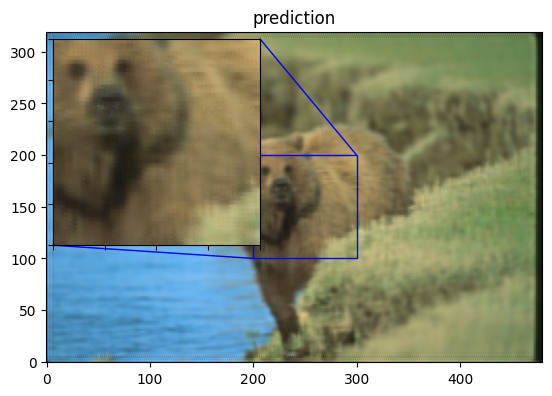

50/50 - 3s - 61ms/step - loss: 0.0216 - val_loss: 0.0071
Epoch 2/50
Mean PSNR for epoch: 23.02
50/50 - 2s - 37ms/step - loss: 0.0065 - val_loss: 0.0050
Epoch 3/50
Mean PSNR for epoch: 23.26
50/50 - 2s - 32ms/step - loss: 0.0054 - val_loss: 0.0046
Epoch 4/50
Mean PSNR for epoch: 23.83
50/50 - 2s - 31ms/step - loss: 0.0052 - val_loss: 0.0045
Epoch 5/50
Mean PSNR for epoch: 23.60
50/50 - 2s - 32ms/step - loss: 0.0051 - val_loss: 0.0045
Epoch 6/50
Mean PSNR for epoch: 23.86
50/50 - 2s - 32ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 7/50
Mean PSNR for epoch: 23.78
50/50 - 2s - 30ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 8/50
Mean PSNR for epoch: 23.42
50/50 - 2s - 31ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 9/50
Mean PSNR for epoch: 23.72
50/50 - 2s - 32ms/step - loss: 0.0050 - val_loss: 0.0043
Epoch 10/50
Mean PSNR for epoch: 24.03
50/50 - 2s - 32ms/step - loss: 0.0049 - val_loss: 0.0043
Epoch 11/50
Mean PSNR for epoch: 23.89
50/50 - 2s - 32ms/step - loss: 0.0049 - val_loss

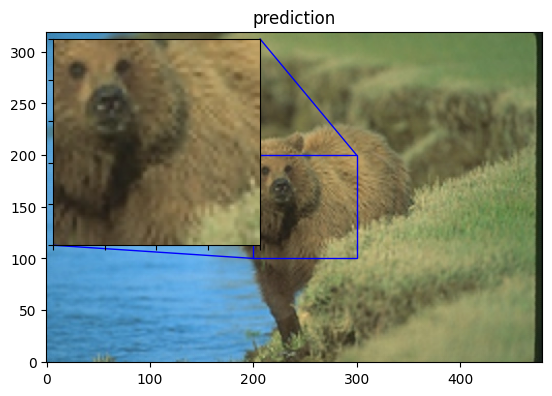

50/50 - 2s - 45ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 22/50
Mean PSNR for epoch: 23.97
50/50 - 2s - 37ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 23/50
Mean PSNR for epoch: 24.15
50/50 - 2s - 32ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 24/50
Mean PSNR for epoch: 23.97
50/50 - 2s - 33ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 25/50
Mean PSNR for epoch: 23.98
50/50 - 2s - 32ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 26/50
Mean PSNR for epoch: 23.79
50/50 - 2s - 32ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 27/50
Mean PSNR for epoch: 23.67
50/50 - 2s - 31ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 28/50
Mean PSNR for epoch: 23.73
50/50 - 2s - 33ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 29/50
Mean PSNR for epoch: 23.96
50/50 - 2s - 45ms/step - loss: 0.0047 - val_loss: 0.0041
Epoch 30/50
Mean PSNR for epoch: 23.92
50/50 - 2s - 37ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 31/50
Mean PSNR for epoch: 23.99
50/50 - 2s - 40ms/step - loss: 0.0046 - 

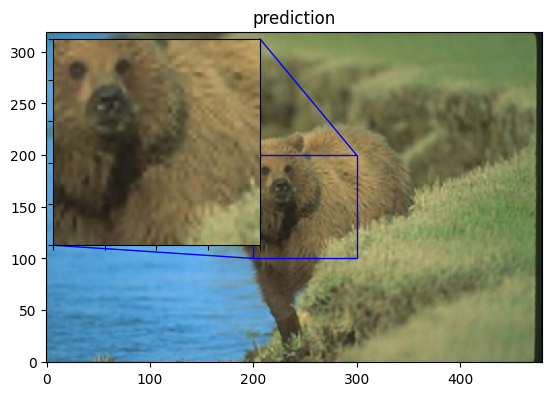

50/50 - 2s - 39ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 42/50
Mean PSNR for epoch: 24.34
50/50 - 2s - 33ms/step - loss: 0.0048 - val_loss: 0.0041
Epoch 43/50
Mean PSNR for epoch: 23.91
50/50 - 2s - 32ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 44/50
Mean PSNR for epoch: 23.88
50/50 - 2s - 32ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 45/50
Mean PSNR for epoch: 24.20
50/50 - 2s - 32ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 46/50
Mean PSNR for epoch: 23.84
50/50 - 2s - 31ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 47/50
Mean PSNR for epoch: 23.90
50/50 - 2s - 31ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 48/50
Mean PSNR for epoch: 23.65
50/50 - 2s - 31ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 49/50
Mean PSNR for epoch: 23.92
50/50 - 2s - 31ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 50/50
Mean PSNR for epoch: 23.81
50/50 - 2s - 33ms/step - loss: 0.0046 - val_loss: 0.0041


In [53]:
epochs = 50

model.compile(
    optimizer=optimizer,
    loss=loss_fn
)

model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=valid_ds,
    verbose=2
)

model.load_weights(checkpoint_filepath)